<div style="display: flex; align-items: center; justify-content: flex-start; text-align: left;">
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/6/68/Logo_universidad_icesi.svg/960px-Logo_universidad_icesi.svg.png" width="300" style="margin-right: 20px;">
    <div>
        <h3 style="margin: 0;">FACULTAD BARBERI DE INGENIERÍA, DISEÑO Y CIENCIAS APLICADAS</h3>
        <h3 style="margin: 0;">ALGORITMOS Y PROGRAMACIÓN III</h3>
    </div>
</div>

# Proyecto Final — Clasificación de Calidad y Tamaño de Frutas

**Integrantes**
- Angy María Hurtado Osorio — A00401755
- Hideki Tamura Hernández — A00348618
- David Vergara Laverde — A00402237

# Notebook 02 — Experimentos de Machine Learning Tradicional

Este notebook entrena, compara y evalúa tres familias de modelos clásicos para una tarea **multi-salida**:

- **Calidad:** `Bad`, `Good`, `Regular`
- **Tamaño:** `small`, `medium`, `large`

Modelos evaluados:

1. **Random Forest**
2. **SVM lineal**
3. **XGBoost**

La entrada de los modelos no son los píxeles crudos, sino un vector de características extraído con `src/utils/helpers.py`. Actualmente el vector incluye un histograma HSV normalizado y una característica de área relativa de la fruta.

## Decisiones metodológicas importantes

Antes de entrenar se aplican cuatro controles para que el experimento sea defendible:

1. **Sin fuga de datos por aumentación.** El split de entrenamiento/prueba se hace únicamente con imágenes originales (`augmented == 0`). Las imágenes aumentadas no se usan en el test.
2. **Manejo del desbalance.** El EDA mostró que `Regular` tiene menos imágenes que `Good`, por lo que se usan pesos de clase cuando el algoritmo lo permite.
3. **Etiquetas verificadas desde `metadata.csv`.** Los nombres de clases no se escriben a mano en un orden arbitrario; se construyen a partir de los códigos reales (`label` y `size_label`).
4. **Rutas consistentes con la estructura final.** Los modelos entrenados se guardan en `../saved_models/`, no en `../models/`.

## 0. Configuración e importaciones

> Ejecutar este notebook desde la carpeta `notebooks/`. Las rutas usan `..` para acceder a la raíz del proyecto.

In [1]:
import os
import sys
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, make_scorer
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# Permite importar módulos desde src/
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.helpers import extract_features_for_ml

# XGBoost es necesario para ejecutar la comparación completa.
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('ADVERTENCIA: xgboost no está instalado. Instala con: pip install xgboost')

# Rutas del proyecto
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
METADATA_PATH = PROCESSED_DIR / 'metadata.csv'
SAVED_MODELS_DIR = PROJECT_ROOT / 'saved_models'
FIGURES_DIR = PROJECT_ROOT / 'docs' / 'figures'

SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20
USE_FEATURE_CACHE = True
RUN_RF_TUNING = False  # Cambiar a True si se desea hacer búsqueda de hiperparámetros del Random Forest.

print('Configuración lista')
print(f'Raíz del proyecto : {PROJECT_ROOT}')
print(f'Metadata esperado : {METADATA_PATH}')
print(f'Modelos guardados : {SAVED_MODELS_DIR}')
print(f'XGBoost disponible: {XGBOOST_AVAILABLE}')

Configuración lista
Raíz del proyecto : /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves
Metadata esperado : /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/data/processed/metadata.csv
Modelos guardados : /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/saved_models
XGBoost disponible: True


## 1. Carga y validación del dataset procesado

Se carga `metadata.csv`, se valida que existan las columnas mínimas y se filtran únicamente las imágenes originales. Esta decisión evita que una imagen aumentada de una fruta aparezca en entrenamiento mientras la imagen original aparece en prueba.

In [2]:
if not METADATA_PATH.exists():
    raise FileNotFoundError(
        f'No se encontró {METADATA_PATH}. Ejecuta primero desde la raíz del proyecto: '
        'python src/data_processing/preprocess.py'
    )

metadata = pd.read_csv(METADATA_PATH)

required_columns = {'file', 'label', 'quality', 'augmented', 'size_category'}
missing_columns = required_columns - set(metadata.columns)
if missing_columns:
    raise ValueError(f'Faltan columnas requeridas en metadata.csv: {sorted(missing_columns)}')

# Codificación de tamaño. Si preprocess.py ya lo trae codificado, esta celda lo respeta.
size_map = {'small': 0, 'medium': 1, 'large': 2}
if 'size_label' not in metadata.columns:
    metadata['size_label'] = metadata['size_category'].map(size_map)

if metadata['size_label'].isna().any():
    bad_values = metadata.loc[metadata['size_label'].isna(), 'size_category'].unique().tolist()
    raise ValueError(f'Hay valores de size_category no reconocidos: {bad_values}')

# Control de fuga de datos: solo originales para el experimento tradicional.
metadata_original = metadata[metadata['augmented'].astype(int) == 0].copy().reset_index(drop=True)
metadata_augmented = metadata[metadata['augmented'].astype(int) == 1].copy().reset_index(drop=True)

print(f'Registros totales en metadata : {len(metadata):,}')
print(f'Imágenes originales usadas    : {len(metadata_original):,}')
print(f'Imágenes aumentadas excluidas : {len(metadata_augmented):,}')
print('\nDistribución de calidad en originales:')
display(metadata_original['quality'].value_counts().to_frame('n_imagenes'))
print('\nDistribución de tamaño en originales:')
display(metadata_original['size_category'].value_counts().to_frame('n_imagenes'))

Registros totales en metadata : 141,975
Imágenes originales usadas    : 28,395
Imágenes aumentadas excluidas : 113,580

Distribución de calidad en originales:


,n_imagenes
quality,
Good,14599
Bad,9142
Regular,4654



Distribución de tamaño en originales:


,n_imagenes
size_category,
large,15305
medium,10540
small,2550


## 2. Nombres correctos de las clases

Para evitar reportes mal rotulados, se construye el orden de las clases a partir de los códigos reales presentes en `metadata.csv`.

In [3]:
quality_translation = {
    'Bad': 'Mala',
    'Good': 'Buena',
    'Regular': 'Regular',
    'bad': 'Mala',
    'good': 'Buena',
    'regular': 'Regular',
}

size_translation = {
    'small': 'Pequeño',
    'medium': 'Mediano',
    'large': 'Grande',
}

quality_by_label = (
    metadata_original
    .groupby('label')['quality']
    .agg(lambda s: s.mode().iloc[0])
    .sort_index()
)
quality_names = [quality_translation.get(str(q), str(q)) for q in quality_by_label.values]
quality_labels = quality_by_label.index.to_list()

size_by_label = (
    metadata_original
    .groupby('size_label')['size_category']
    .agg(lambda s: s.mode().iloc[0])
    .sort_index()
)
size_names = [size_translation.get(str(s), str(s)) for s in size_by_label.values]
size_labels = size_by_label.index.to_list()

print('Mapa calidad label -> nombre:')
display(quality_by_label.to_frame('quality'))
print('quality_names usados en reportes:', quality_names)

print('\nMapa tamaño size_label -> nombre:')
display(size_by_label.to_frame('size_category'))
print('size_names usados en reportes:', size_names)

Mapa calidad label -> nombre:


,quality
label,
0,Bad
1,Good
2,Regular


quality_names usados en reportes: ['Mala', 'Buena', 'Regular']

Mapa tamaño size_label -> nombre:


,size_category
size_label,
0,small
1,medium
2,large


size_names usados en reportes: ['Pequeño', 'Mediano', 'Grande']


## 3. Extracción de características

Cada imagen se convierte en un vector numérico usando `extract_features_for_ml()` de `src/utils/helpers.py`. El resultado se guarda en caché dentro de `data/processed/` para no recalcular todas las características cada vez que se abra el notebook.

La caché es local y **no debe subirse a Git** si `data/` está ignorado en `.gitignore`.

In [4]:
FEATURE_CACHE_PATH = PROCESSED_DIR / 'features_ml_original.npz'
FEATURE_META_CACHE_PATH = PROCESSED_DIR / 'features_ml_original_metadata.csv'


def extract_features_from_df(df: pd.DataFrame, base_dir: Path):
    """Extrae features manteniendo alineadas las etiquetas solo para imágenes válidas."""
    features = []
    valid_indices = []
    failed_files = []

    for idx, row in tqdm(df.iterrows(), total=len(df), desc='Extrayendo features'):
        img_path = base_dir / str(row['file'])
        try:
            feat = extract_features_for_ml(str(img_path)).flatten()
            features.append(feat)
            valid_indices.append(idx)
        except Exception as exc:
            failed_files.append((str(row['file']), str(exc)))

    if not features:
        raise RuntimeError('No se pudo extraer ninguna característica. Revisa las rutas en metadata.csv.')

    X_local = np.asarray(features, dtype=np.float32)
    valid_metadata = df.loc[valid_indices].reset_index(drop=True)

    if failed_files:
        print(f'ADVERTENCIA: {len(failed_files)} imágenes fallaron al cargarse. Se excluyen del entrenamiento.')
        print('Primeros fallos:', failed_files[:5])

    return X_local, valid_metadata, failed_files


if USE_FEATURE_CACHE and FEATURE_CACHE_PATH.exists() and FEATURE_META_CACHE_PATH.exists():
    print('Cargando features desde caché...')
    X = np.load(FEATURE_CACHE_PATH)['X']
    metadata_features = pd.read_csv(FEATURE_META_CACHE_PATH)
else:
    print('Calculando features desde las imágenes originales...')
    X, metadata_features, failed_files = extract_features_from_df(metadata_original, PROCESSED_DIR)

    if USE_FEATURE_CACHE:
        np.savez_compressed(FEATURE_CACHE_PATH, X=X)
        metadata_features.to_csv(FEATURE_META_CACHE_PATH, index=False)
        print(f'Caché guardada en: {FEATURE_CACHE_PATH}')

print(f'X shape: {X.shape}')
print(f'Registros válidos: {len(metadata_features):,}')

Calculando features desde las imágenes originales...


Extrayendo features:   0%|          | 0/28395 [00:00<?, ?it/s]

Caché guardada en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/data/processed/features_ml_original.npz
X shape: (28395, 513)
Registros válidos: 28,395


## 4. Split de entrenamiento y prueba

Se usa `stratify=y_quality` para conservar la proporción de clases de calidad en train/test. El conjunto de prueba contiene solo imágenes originales.

In [5]:
y_quality = metadata_features['label'].astype(int).values
y_size = metadata_features['size_label'].astype(int).values

X_train, X_test, y_train_quality, y_test_quality, y_train_size, y_test_size = train_test_split(
    X,
    y_quality,
    y_size,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_quality,
)

y_train = np.column_stack([y_train_quality, y_train_size])
y_test = np.column_stack([y_test_quality, y_test_size])

print(f'X_train: {X_train.shape}')
print(f'X_test : {X_test.shape}')

split_summary = pd.DataFrame({
    'quality_train': pd.Series(y_train_quality).value_counts().sort_index(),
    'quality_test': pd.Series(y_test_quality).value_counts().sort_index(),
})
split_summary.index = [quality_names[i] if i < len(quality_names) else str(i) for i in split_summary.index]
display(split_summary)

X_train: (22716, 513)
X_test : (5679, 513)


,quality_train,quality_test
Mala,7314,1828
Buena,11679,2920
Regular,3723,931


## 5. Funciones de evaluación

Se reportan métricas separadas para calidad y tamaño. Para el problema de desbalance, se revisa especialmente el **F1 macro** y el desempeño de la clase `Regular`, no solo el accuracy global.

In [6]:
def evaluate_model_outputs(model_name: str, y_true: np.ndarray, y_pred: np.ndarray, save_figure: bool = True):
    """Imprime reportes, grafica matrices de confusión y retorna métricas resumen."""
    y_true_quality, y_true_size = y_true[:, 0], y_true[:, 1]
    y_pred_quality, y_pred_size = y_pred[:, 0], y_pred[:, 1]

    print('=' * 72)
    print(f'EVALUACIÓN: {model_name}')
    print('=' * 72)

    print('\nReporte de clasificación — Calidad')
    print(classification_report(
        y_true_quality,
        y_pred_quality,
        labels=quality_labels,
        target_names=quality_names,
        zero_division=0,
    ))

    print('Reporte de clasificación — Tamaño')
    print(classification_report(
        y_true_size,
        y_pred_size,
        labels=size_labels,
        target_names=size_names,
        zero_division=0,
    ))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    cm_quality = confusion_matrix(y_true_quality, y_pred_quality, labels=quality_labels)
    sns.heatmap(cm_quality, annot=True, fmt='d', cmap='Blues',
                xticklabels=quality_names, yticklabels=quality_names, ax=axes[0])
    axes[0].set_title(f'{model_name} — Matriz de Confusión Calidad')
    axes[0].set_xlabel('Predicción')
    axes[0].set_ylabel('Real')

    cm_size = confusion_matrix(y_true_size, y_pred_size, labels=size_labels)
    sns.heatmap(cm_size, annot=True, fmt='d', cmap='Greens',
                xticklabels=size_names, yticklabels=size_names, ax=axes[1])
    axes[1].set_title(f'{model_name} — Matriz de Confusión Tamaño')
    axes[1].set_xlabel('Predicción')
    axes[1].set_ylabel('Real')

    plt.tight_layout()
    if save_figure:
        safe_name = model_name.lower().replace(' ', '_').replace('/', '_')
        fig_path = FIGURES_DIR / f'confusion_{safe_name}.pdf'
        plt.savefig(fig_path, bbox_inches='tight')
        print(f'Figura guardada en: {fig_path}')
    plt.show()

    metrics = {
        'modelo': model_name,
        'accuracy_calidad': accuracy_score(y_true_quality, y_pred_quality),
        'f1_macro_calidad': f1_score(y_true_quality, y_pred_quality, average='macro', zero_division=0),
        'accuracy_tamaño': accuracy_score(y_true_size, y_pred_size),
        'f1_macro_tamaño': f1_score(y_true_size, y_pred_size, average='macro', zero_division=0),
    }
    metrics['f1_macro_promedio'] = (metrics['f1_macro_calidad'] + metrics['f1_macro_tamaño']) / 2
    return metrics


def multioutput_f1_macro_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """Scorer compatible con RandomizedSearchCV para salidas [calidad, tamaño]."""
    return (
        f1_score(y_true[:, 0], y_pred[:, 0], average='macro', zero_division=0)
        + f1_score(y_true[:, 1], y_pred[:, 1], average='macro', zero_division=0)
    ) / 2


multioutput_f1_macro_scorer = make_scorer(multioutput_f1_macro_score)


## 6. Definición de modelos

- **Random Forest:** usa `class_weight='balanced'`, adecuado para el desbalance de calidad y tamaño.
- **SVM lineal:** usa `class_weight='balanced'` y `StandardScaler`, necesario para modelos basados en margen.
- **XGBoost:** usa `sample_weight` basado en la clase de calidad para reducir el sesgo hacia la clase mayoritaria.

> Si `xgboost` no está instalado, agregarlo al entorno con `pip install xgboost` o incluir `xgboost>=2.0` en `requirements.txt`.

In [9]:
models = {}

models['Random Forest'] = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            class_weight='balanced',
            n_jobs=-1,
        ),
        n_jobs=-1,
    )),
])

models['SVM lineal'] = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', MultiOutputClassifier(
        LinearSVC(
            class_weight='balanced',
            max_iter=10000,
            random_state=RANDOM_STATE,
            dual='auto',
        ),
        n_jobs=-1,
    )),
])

if XGBOOST_AVAILABLE:
    xgb_base = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.90,
        colsample_bytree=0.90,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    models['XGBoost'] = Pipeline([
        ('classifier', MultiOutputClassifier(xgb_base, n_jobs=-1)),
    ])
else:
    raise ImportError(
        'Este notebook está preparado para reportar Random Forest, SVM y XGBoost. '
        'Instala XGBoost antes de ejecutar la comparación completa: pip install xgboost'
    )

print('Modelos definidos:')
for name in models:
    print(f'  - {name}')

Modelos definidos:
  - Random Forest
  - SVM lineal
  - XGBoost


## 7. Entrenamiento y comparación

Se entrena cada modelo con el mismo split para que la comparación sea justa. El criterio principal de selección es `f1_macro_promedio`, porque combina el desempeño macro de calidad y tamaño y no queda dominado por la clase mayoritaria.


Entrenando Random Forest...
EVALUACIÓN: Random Forest

Reporte de clasificación — Calidad
              precision    recall  f1-score   support

        Mala       0.97      0.98      0.97      1828
       Buena       0.99      0.98      0.99      2920
     Regular       0.97      0.97      0.97       931

    accuracy                           0.98      5679
   macro avg       0.98      0.98      0.98      5679
weighted avg       0.98      0.98      0.98      5679

Reporte de clasificación — Tamaño
              precision    recall  f1-score   support

     Pequeño       0.98      0.86      0.92       504
     Mediano       0.93      0.95      0.94      2143
      Grande       0.96      0.98      0.97      3032

    accuracy                           0.95      5679
   macro avg       0.96      0.93      0.94      5679
weighted avg       0.95      0.95      0.95      5679

Figura guardada en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/docs/figures/confusion_random

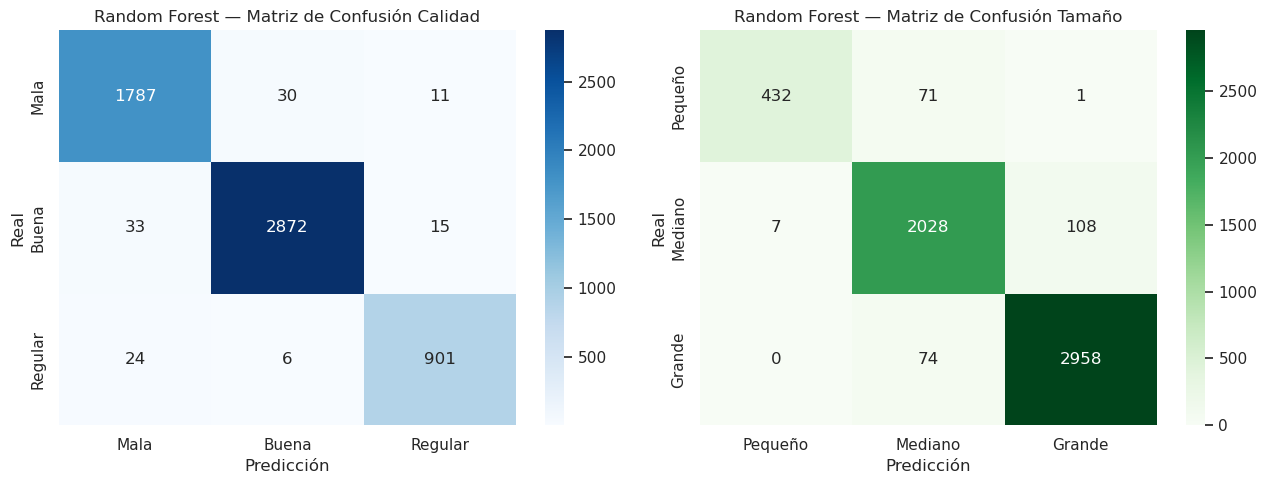


Entrenando SVM lineal...
EVALUACIÓN: SVM lineal

Reporte de clasificación — Calidad
              precision    recall  f1-score   support

        Mala       0.83      0.88      0.85      1828
       Buena       0.94      0.87      0.91      2920
     Regular       0.80      0.89      0.84       931

    accuracy                           0.88      5679
   macro avg       0.86      0.88      0.87      5679
weighted avg       0.88      0.88      0.88      5679

Reporte de clasificación — Tamaño
              precision    recall  f1-score   support

     Pequeño       0.95      0.91      0.93       504
     Mediano       0.95      0.98      0.97      2143
      Grande       0.99      0.98      0.99      3032

    accuracy                           0.97      5679
   macro avg       0.97      0.96      0.96      5679
weighted avg       0.97      0.97      0.97      5679

Figura guardada en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/docs/figures/confusion_svm_lineal.p

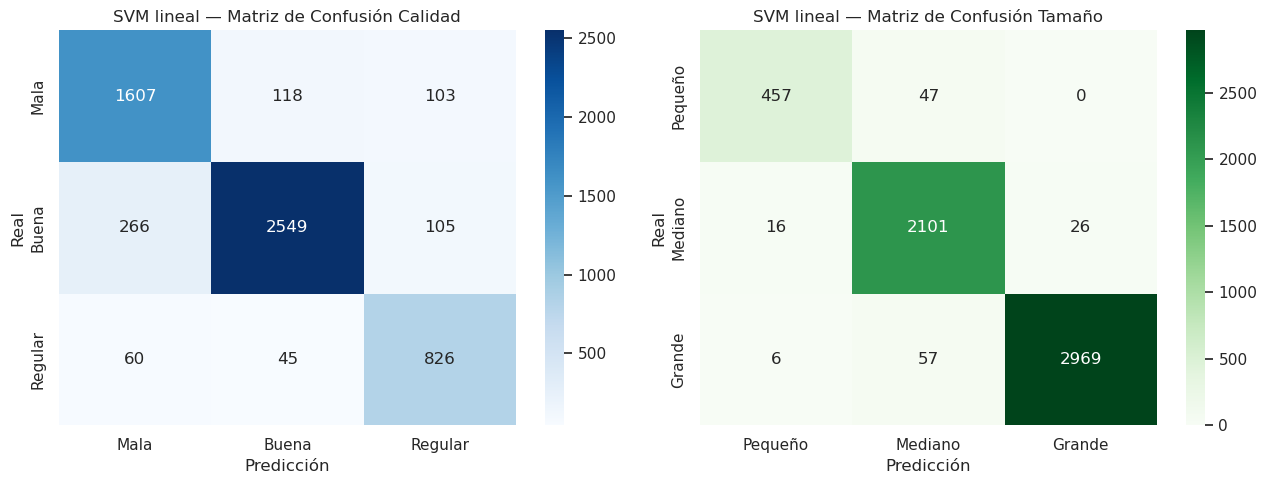


Entrenando XGBoost...
EVALUACIÓN: XGBoost

Reporte de clasificación — Calidad
              precision    recall  f1-score   support

        Mala       0.97      0.97      0.97      1828
       Buena       0.99      0.97      0.98      2920
     Regular       0.94      0.98      0.96       931

    accuracy                           0.97      5679
   macro avg       0.97      0.98      0.97      5679
weighted avg       0.97      0.97      0.97      5679

Reporte de clasificación — Tamaño
              precision    recall  f1-score   support

     Pequeño       0.97      0.89      0.93       504
     Mediano       0.94      0.97      0.95      2143
      Grande       0.98      0.97      0.98      3032

    accuracy                           0.96      5679
   macro avg       0.96      0.94      0.95      5679
weighted avg       0.96      0.96      0.96      5679

Figura guardada en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/docs/figures/confusion_xgboost.pdf


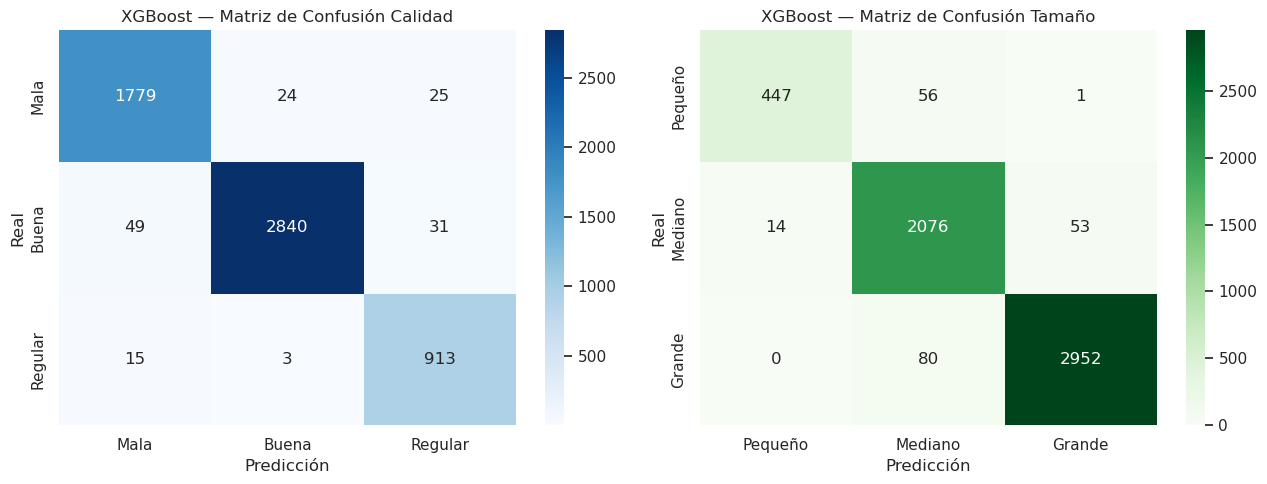


Resumen comparativo:


,modelo,accuracy_calidad,f1_macro_calidad,accuracy_tamaño,f1_macro_tamaño,f1_macro_promedio,tiempo_entrenamiento_seg
0,XGBoost,0.974115,0.970594,0.964078,0.952540,0.961567,64.139660
1,Random Forest,0.979046,0.976253,0.954041,0.941993,0.959123,6.682686
2,SVM lineal,0.877267,0.866819,0.973235,0.960487,0.913653,528.304199


Resultados guardados en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/saved_models/traditional_models_results.csv


In [10]:
trained_models = {}
results = []

# Peso por muestra para XGBoost. Se calcula sobre calidad porque allí está el desbalance más relevante.
sample_weight_quality = compute_sample_weight(class_weight='balanced', y=y_train_quality)

for model_name, model in models.items():
    print('\n' + '=' * 72)
    print(f'Entrenando {model_name}...')
    print('=' * 72)
    start = time.time()

    fit_params = {}
    if model_name == 'XGBoost':
        # Pipeline -> classifier -> MultiOutputClassifier -> sample_weight para cada salida.
        fit_params['classifier__sample_weight'] = sample_weight_quality

    model.fit(X_train, y_train, **fit_params)
    elapsed = time.time() - start

    y_pred = model.predict(X_test)
    metrics = evaluate_model_outputs(model_name, y_test, y_pred, save_figure=True)
    metrics['tiempo_entrenamiento_seg'] = elapsed

    trained_models[model_name] = model
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values('f1_macro_promedio', ascending=False).reset_index(drop=True)
print('\nResumen comparativo:')
display(results_df)

results_path = SAVED_MODELS_DIR / 'traditional_models_results.csv'
results_df.to_csv(results_path, index=False)
print(f'Resultados guardados en: {results_path}')

## 8. Ajuste de hiperparámetros del Random Forest

La siguiente celda permite hacer una búsqueda aleatoria de hiperparámetros para Random Forest. Está desactivada por defecto para que el notebook pueda ejecutarse más rápido. Si el equipo tiene un computador con más recursos, cambiar `RUN_RF_TUNING = True` en la primera celda.

In [11]:
if RUN_RF_TUNING:
    param_dist = {
        'classifier__estimator__n_estimators': [150, 200, 300, 400],
        'classifier__estimator__max_depth': [None, 10, 20, 30],
        'classifier__estimator__min_samples_split': [2, 5, 10],
        'classifier__estimator__min_samples_leaf': [1, 2, 4],
    }

    rf_search = RandomizedSearchCV(
        estimator=models['Random Forest'],
        param_distributions=param_dist,
        n_iter=10,
        cv=3,
        scoring=multioutput_f1_macro_scorer,
        n_jobs=-1,
        verbose=2,
        random_state=RANDOM_STATE,
    )

    rf_search.fit(X_train, y_train)
    print('Mejores parámetros Random Forest:')
    print(rf_search.best_params_)

    tuned_rf_model = rf_search.best_estimator_
    tuned_pred = tuned_rf_model.predict(X_test)
    tuned_metrics = evaluate_model_outputs('Random Forest Tuned', y_test, tuned_pred, save_figure=True)
    tuned_metrics['tiempo_entrenamiento_seg'] = np.nan

    trained_models['Random Forest Tuned'] = tuned_rf_model
    results_df = pd.concat([results_df, pd.DataFrame([tuned_metrics])], ignore_index=True)
    results_df = results_df.sort_values('f1_macro_promedio', ascending=False).reset_index(drop=True)
    display(results_df)
else:
    print('Búsqueda de hiperparámetros desactivada. Para ejecutarla, cambiar RUN_RF_TUNING = True en la celda 0.')

Búsqueda de hiperparámetros desactivada. Para ejecutarla, cambiar RUN_RF_TUNING = True en la celda 0.


## 9. Selección y guardado del modelo final

Se guarda el mejor modelo según `f1_macro_promedio`. Además, se guarda una copia específica del Random Forest para mantener compatibilidad con `app.py` si la aplicación está configurada para cargar `best_rf_multioutput.pkl`.

In [12]:
best_model_name = results_df.iloc[0]['modelo']
best_model = trained_models[best_model_name]

print(f'Mejor modelo según f1_macro_promedio: {best_model_name}')
display(results_df.head())

# Guardar todos los modelos entrenados.
model_name_to_file = {
    'Random Forest': 'random_forest_multioutput.pkl',
    'SVM lineal': 'svm_lineal_multioutput.pkl',
    'XGBoost': 'xgboost_multioutput.pkl',
    'Random Forest Tuned': 'random_forest_tuned_multioutput.pkl',
}

for name, model in trained_models.items():
    filename = model_name_to_file.get(name, name.lower().replace(' ', '_') + '.pkl')
    path = SAVED_MODELS_DIR / filename
    joblib.dump(model, path)
    print(f'{name} guardado en: {path}')

# Guardar el mejor modelo tradicional general.
best_path = SAVED_MODELS_DIR / 'best_traditional_multioutput.pkl'
joblib.dump(best_model, best_path)
print(f'\nMejor modelo tradicional guardado en: {best_path}')

# Compatibilidad con versiones anteriores de app.py que esperan este nombre.
rf_compat_path = SAVED_MODELS_DIR / 'best_rf_multioutput.pkl'
joblib.dump(trained_models['Random Forest'], rf_compat_path)
print(f'Copia de Random Forest guardada para compatibilidad en: {rf_compat_path}')

# Guardar metadatos útiles para inferencia y reporte.
metadata_out = {
    'best_model_name': best_model_name,
    'quality_labels': quality_labels,
    'quality_names': quality_names,
    'size_labels': size_labels,
    'size_names': size_names,
    'feature_dim': int(X_train.shape[1]),
    'test_size': TEST_SIZE,
    'random_state': RANDOM_STATE,
}
metadata_model_path = SAVED_MODELS_DIR / 'traditional_model_metadata.json'
with open(metadata_model_path, 'w', encoding='utf-8') as f:
    json.dump(metadata_out, f, ensure_ascii=False, indent=2)
print(f'Metadatos guardados en: {metadata_model_path}')

Mejor modelo según f1_macro_promedio: XGBoost


,modelo,accuracy_calidad,f1_macro_calidad,accuracy_tamaño,f1_macro_tamaño,f1_macro_promedio,tiempo_entrenamiento_seg
0,XGBoost,0.974115,0.970594,0.964078,0.952540,0.961567,64.139660
1,Random Forest,0.979046,0.976253,0.954041,0.941993,0.959123,6.682686
2,SVM lineal,0.877267,0.866819,0.973235,0.960487,0.913653,528.304199


Random Forest guardado en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/saved_models/random_forest_multioutput.pkl
SVM lineal guardado en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/saved_models/svm_lineal_multioutput.pkl
XGBoost guardado en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/saved_models/xgboost_multioutput.pkl

Mejor modelo tradicional guardado en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/saved_models/best_traditional_multioutput.pkl
Copia de Random Forest guardada para compatibilidad en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/saved_models/best_rf_multioutput.pkl
Metadatos guardados en: /home/davidvl/Desktop/ICESI/SemestreVII/APO/Proyecto/sosaSlaves/saved_models/traditional_model_metadata.json


## 10. Conclusiones del experimento

Al finalizar la ejecución completa, usar la tabla comparativa para redactar el informe:

- El modelo seleccionado debe justificarse por `f1_macro_promedio`, no solo por accuracy.
- Revisar especialmente la clase `Regular`, porque es la clase minoritaria y puede quedar oculta si solo se mira el accuracy global.
- Las matrices de confusión permiten verificar si el modelo está confundiendo `Regular` con `Good` o `Bad`.
- Los modelos se guardan en `saved_models/`, por lo que esa carpeta debe existir localmente pero normalmente no se sube a Git por peso.

Este notebook queda alineado con los problemas detectados: control de fuga de datos, tratamiento del desbalance y rutas coherentes con la estructura final del proyecto.